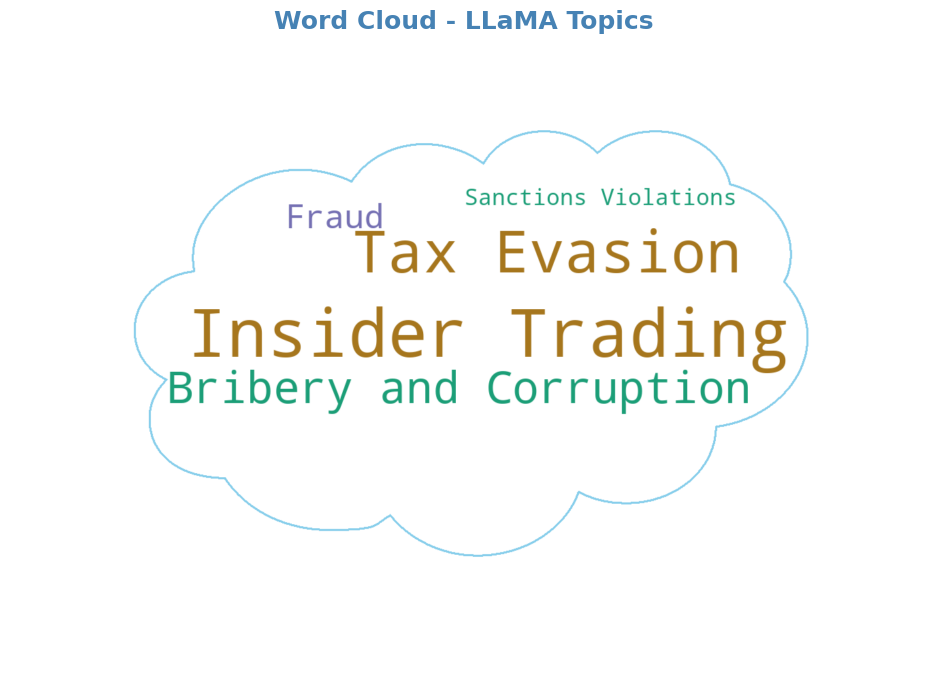

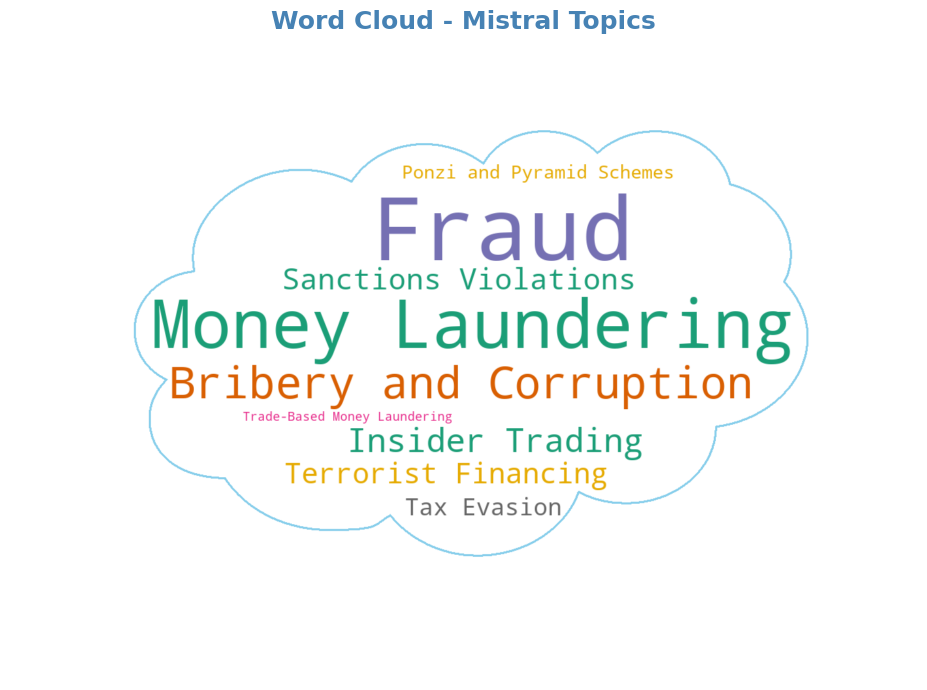

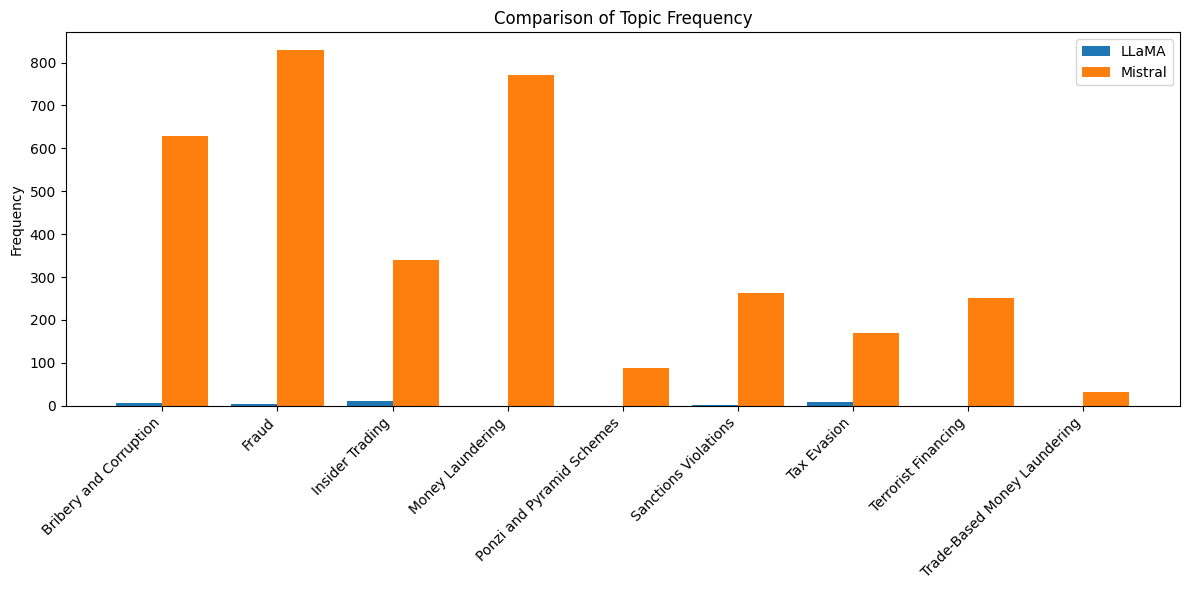

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
from PIL import Image
import ast
import os

# Define the relevant topics
predefined_topics = [
    "Money Laundering", "Terrorist Financing", "Sanctions Violations",
    "Fraud", "Tax Evasion", "Bribery and Corruption",
    "Insider Trading", "Ponzi and Pyramid Schemes", "Trade-Based Money Laundering"
]

# Load data
df_llama = pd.read_excel("./llm/prediction_dfllama_cleaned.xlsx")
df_mistral = pd.read_excel("./llm/prediction_dfmistral.xlsx")

# Helper to clean and extract valid topics
def extract_valid_topics(df):
    topic_counts = {}
    for topics_str in df["related_topics"].dropna():
        try:
            topics = ast.literal_eval(str(topics_str))
            for topic in topics:
                if topic in predefined_topics:
                    topic_counts[topic] = topic_counts.get(topic, 0) + 1
        except Exception as e:
            continue
    return topic_counts

# Load cloud-shaped mask (ensure the image file exists)
def load_cloud_mask(path="cloud_mask.png"):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Cloud mask not found at {path}. Please provide a valid PNG mask.")
    mask = np.array(Image.open(path))
    return mask

# Generate fancy word clouds with a cloud mask
def generate_wordcloud(topic_counts, title, filename, mask):
    wordcloud = WordCloud(
        width=1000, height=600,
        background_color='white',
        colormap='Dark2',
        mask=mask,
        contour_width=3,
        contour_color='skyblue',
        prefer_horizontal=0.95
    ).generate_from_frequencies(topic_counts)

    plt.figure(figsize=(12, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=18, fontweight='bold', color='steelblue')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# Count topics
llama_counts = extract_valid_topics(df_llama)
mistral_counts = extract_valid_topics(df_mistral)

# Load cloud mask
cloud_mask = load_cloud_mask("cloud_mask.png")

# Generate masked word clouds
generate_wordcloud(llama_counts, "Word Cloud - LLaMA Topics", "llama_wordcloud_masked.png", cloud_mask)
generate_wordcloud(mistral_counts, "Word Cloud - Mistral Topics", "mistral_wordcloud_masked.png", cloud_mask)

# Bar chart comparing topic frequencies
def plot_topic_comparison(counts1, counts2):
    topics = list(set(counts1.keys()).union(set(counts2.keys())))
    topics.sort()
    llama_vals = [counts1.get(topic, 0) for topic in topics]
    mistral_vals = [counts2.get(topic, 0) for topic in topics]

    x = range(len(topics))
    plt.figure(figsize=(12, 6))
    plt.bar(x, llama_vals, width=0.4, label='LLaMA', align='center')
    plt.bar([p + 0.4 for p in x], mistral_vals, width=0.4, label='Mistral', align='center')
    plt.xticks([p + 0.2 for p in x], topics, rotation=45, ha='right')
    plt.ylabel("Frequency")
    plt.title("Comparison of Topic Frequency")
    plt.legend()
    plt.tight_layout()
    plt.savefig("topic_comparison_barplot.png")
    plt.show()

plot_topic_comparison(llama_counts, mistral_counts)


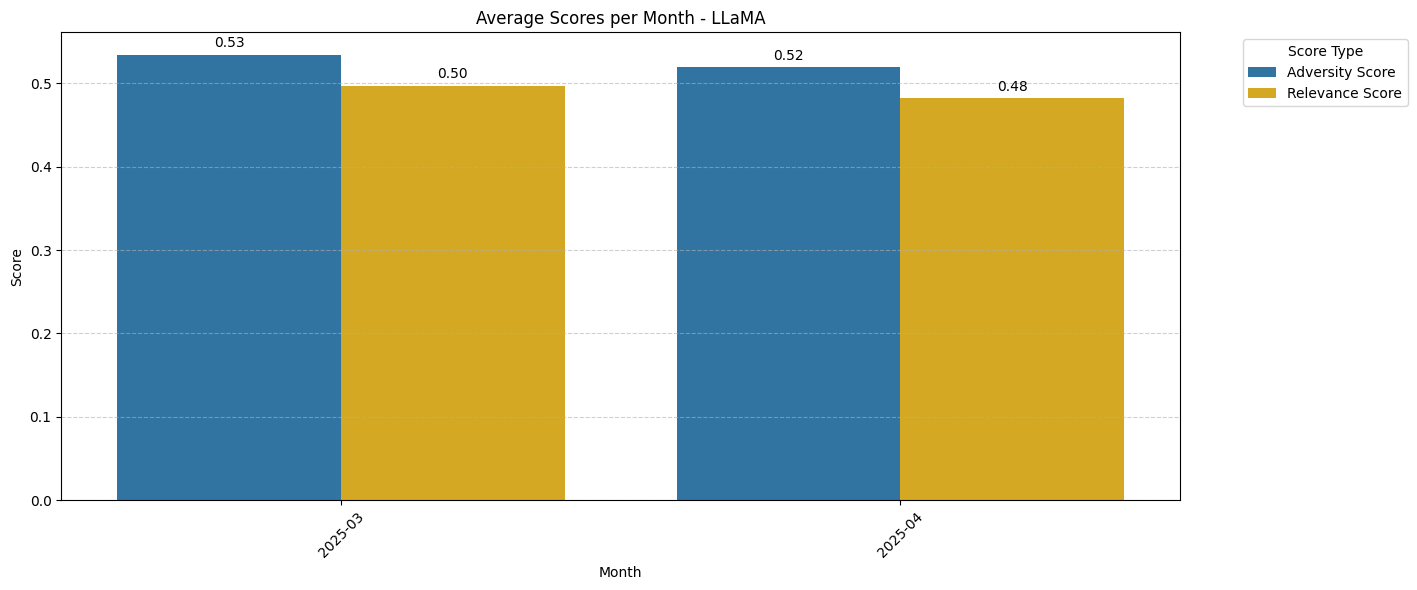

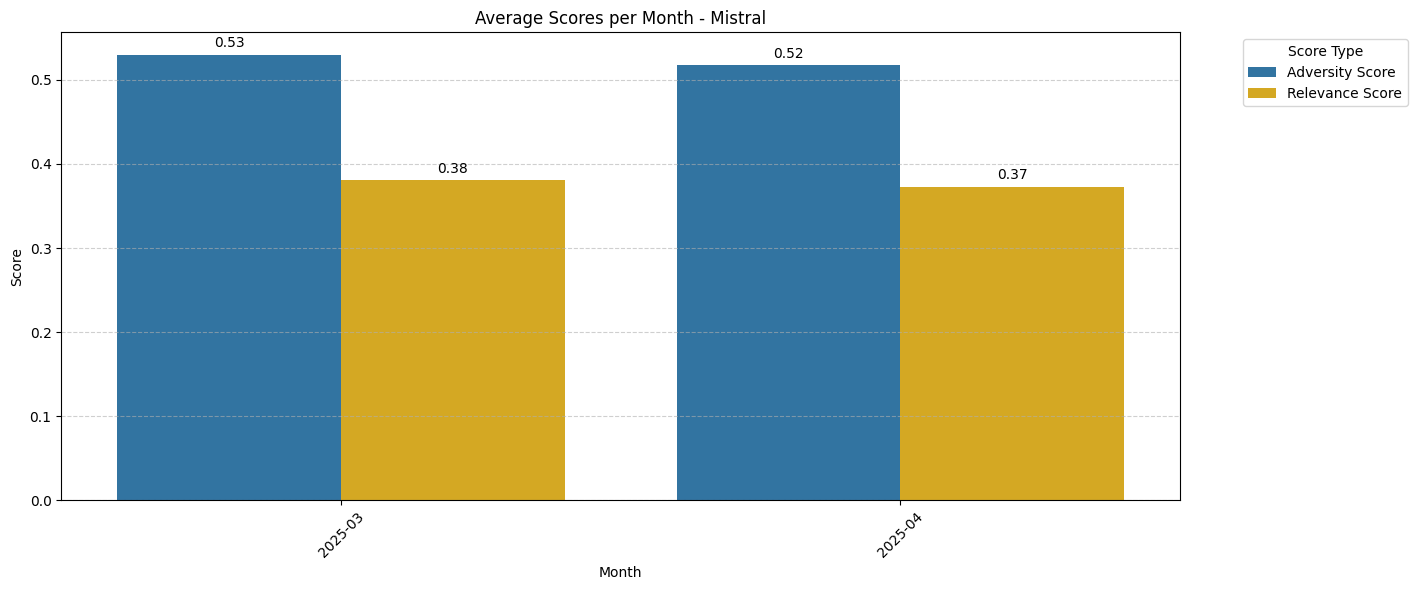

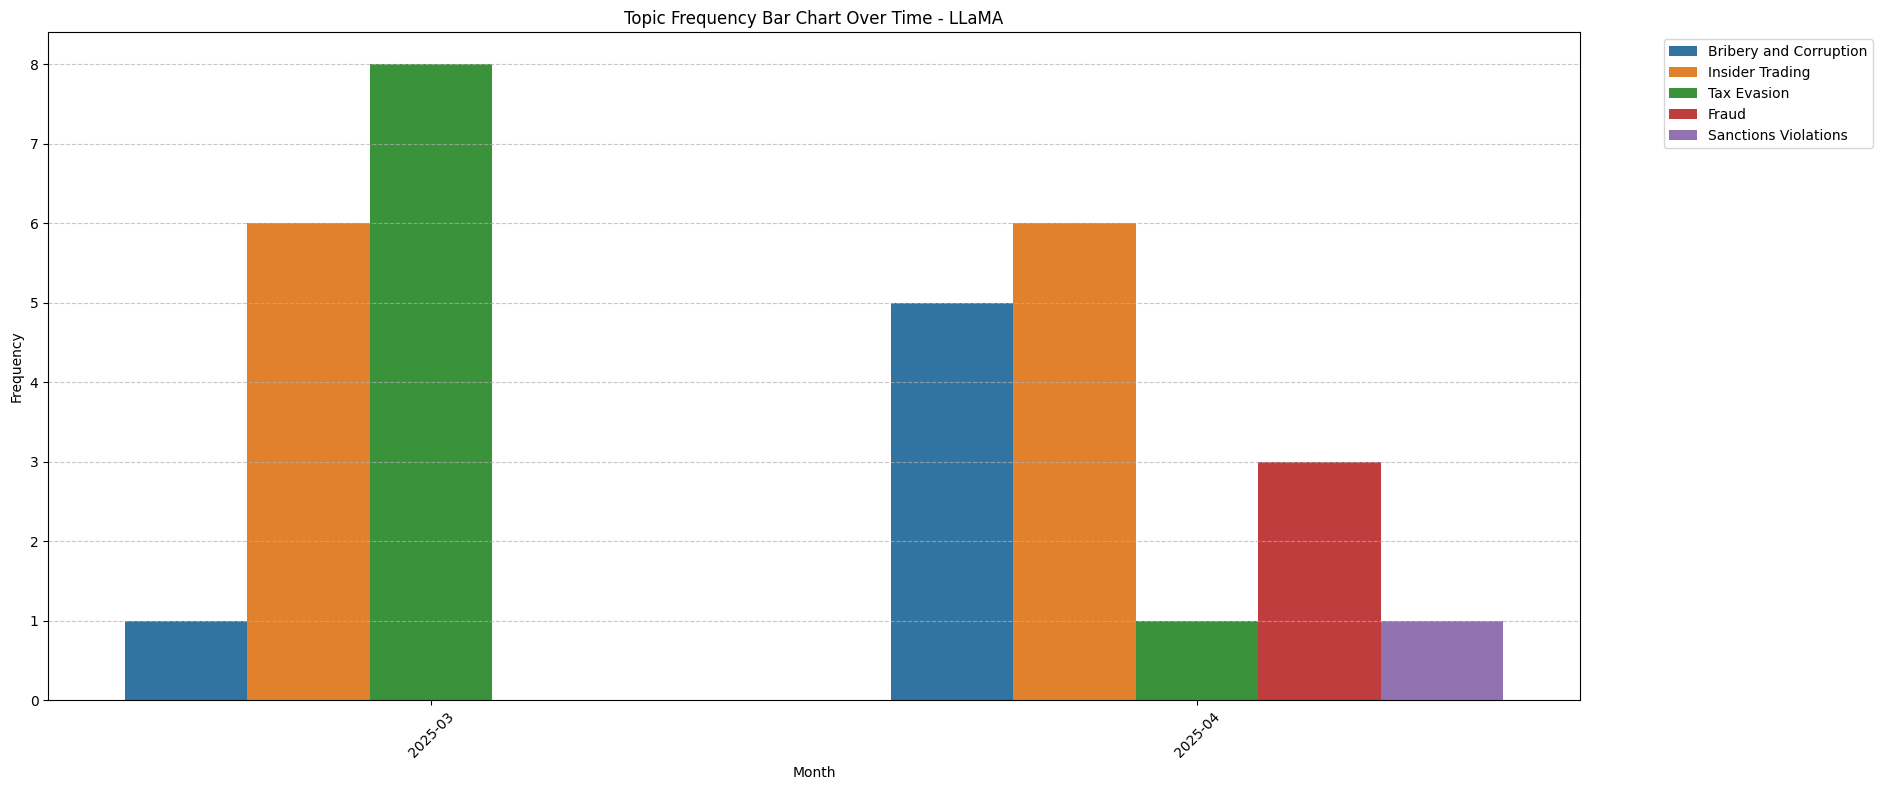

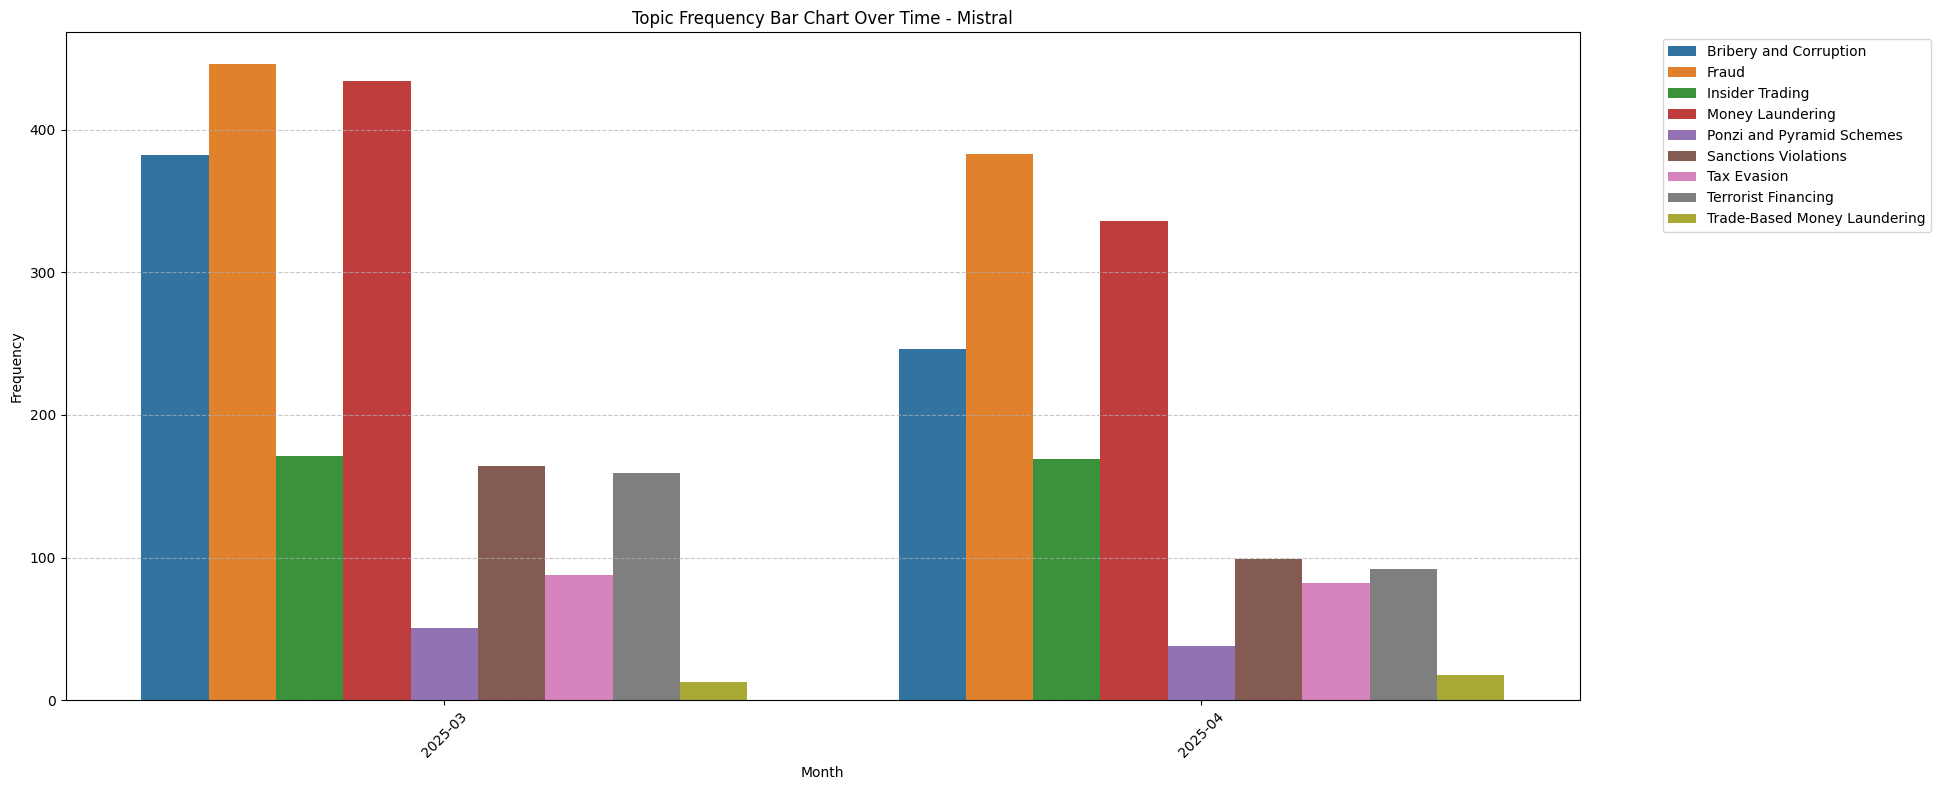

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Load files
df_llama = pd.read_excel("./llm/prediction_dfllama_cleaned.xlsx")
df_mistral = pd.read_excel("./llm/prediction_dfmistral.xlsx")
df_dates = pd.read_excel("./sample_labelled/sample_labelled.xlsx")

# Step 1: Clean and parse date
df_dates["published_date"] = pd.to_datetime(df_dates["published_date"], errors="coerce")

# Step 2: Align dates with predictions
df_llama["published_date"] = df_dates["published_date"]
df_mistral["published_date"] = df_dates["published_date"]

# Step 3: Extract month for trend analysis
df_llama["month"] = df_llama["published_date"].dt.to_period("M")
df_mistral["month"] = df_mistral["published_date"].dt.to_period("M")

def plot_score_trends(df, label):
    trend_df = df.groupby("month")[["adverse_probability", "financial_crime_relevance"]].mean().reset_index()
    trend_df["month"] = trend_df["month"].astype(str)

    # Melt and rename for clarity
    trend_df_melted = trend_df.melt(
        id_vars="month", 
        value_vars=["adverse_probability", "financial_crime_relevance"],
        var_name="Score Type", 
        value_name="Average Score"
    )
    trend_df_melted["Score Type"] = trend_df_melted["Score Type"].map({
        "adverse_probability": "Adversity Score",
        "financial_crime_relevance": "Relevance Score"
    })

    # Fancy palette
    custom_palette = {
        "Adversity Score": "#1f77b4", 
        "Relevance Score": "#f2b705"
    }

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=trend_df_melted,
        x="month", 
        y="Average Score", 
        hue="Score Type",
        palette=custom_palette
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3)

    plt.title(f"Average Scores per Month - {label}")
    plt.xlabel("Month")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    plt.legend(title="Score Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.savefig(f"{label.lower()}_score_trends_bar.png")
    plt.show()

plot_score_trends(df_llama, "LLaMA")
plot_score_trends(df_mistral, "Mistral")

# Step 5: Topic frequency trend over time
def extract_valid_topics(df):
    topic_counts = []
    predefined_topics = [
        "Money Laundering", "Terrorist Financing", "Sanctions Violations",
        "Fraud", "Tax Evasion", "Bribery and Corruption",
        "Insider Trading", "Ponzi and Pyramid Schemes", "Trade-Based Money Laundering"
    ]
    for idx, row in df.iterrows():
        try:
            topics = ast.literal_eval(str(row["related_topics"]))
            for topic in topics:
                if topic in predefined_topics:
                    topic_counts.append((row["month"], topic))
        except:
            continue
    return pd.DataFrame(topic_counts, columns=["month", "topic"])

def plot_topic_trend_bar(df, label):
    topic_df = extract_valid_topics(df)
    topic_df = topic_df.groupby(["month", "topic"]).size().reset_index(name="count")
    topic_df["month"] = topic_df["month"].astype(str)

    plt.figure(figsize=(16, 8))
    sns.barplot(data=topic_df, x="month", y="count", hue="topic", dodge=True)
    plt.title(f"Topic Frequency Bar Chart Over Time - {label}")
    plt.xlabel("Month")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.savefig(f"{label.lower()}_topic_bar_chart.png")
    plt.show()

plot_topic_trend_bar(df_llama, "LLaMA")
plot_topic_trend_bar(df_mistral, "Mistral")
